# NB35 — Proton Stability: The Non-GUT Prediction
## Why the Solenoid Predicts No Proton Decay

The Grand Unified Theory (GUT) paradigm makes a **dramatic prediction**: the proton 
should decay. In SU(5), the three SM gauge groups unify into a single group at
$M_{\text{GUT}} \sim 10^{15}$ GeV, mediated by heavy X/Y bosons that violate
baryon number. The predicted proton lifetime is $\tau_p \sim 10^{31-36}$ years.

**Super-Kamiokande** has observed $\sim 5 \times 10^{33}$ proton-years with 
**zero** decay events, pushing bounds to $\tau_p > 10^{34}$ years — already 
ruling out minimal SU(5).

The solenoid makes a **different structural prediction**: there IS no GUT group.
The three gauge couplings are set at different levels of the primorial cascade
(NB32), not by descent from a single unified coupling. If no unification occurs,
there are **no X/Y bosons**, and the dominant proton decay channel vanishes.

**Tests:**
1. Do the SM couplings actually converge under one-loop RG running?
2. What does GUT theory predict vs. experimental bounds?
3. What does the solenoid's cascade structure predict instead?
4. Can we distinguish the two predictions experimentally?


GUT CONVERGENCE ANALYSIS — Standard Model (no SUSY)

  Couplings at M_Z = 91.1876 GeV:
    1/α₁ = 59.00  (SU(5) normalization)
    1/α₂ = 29.57
    1/α₃ = 8.47

  Pairwise crossings:
    α₁ = α₂ at μ = 1.02e+13 GeV  (log₁₀ = 13.0)
    α₁ = α₃ at μ = 2.40e+14 GeV  (log₁₀ = 14.4)
    α₂ = α₃ at μ = 9.52e+16 GeV  (log₁₀ = 17.0)

  Spread: 4.0 decades
  Triple-point convergence: NO — 4.0 decades apart


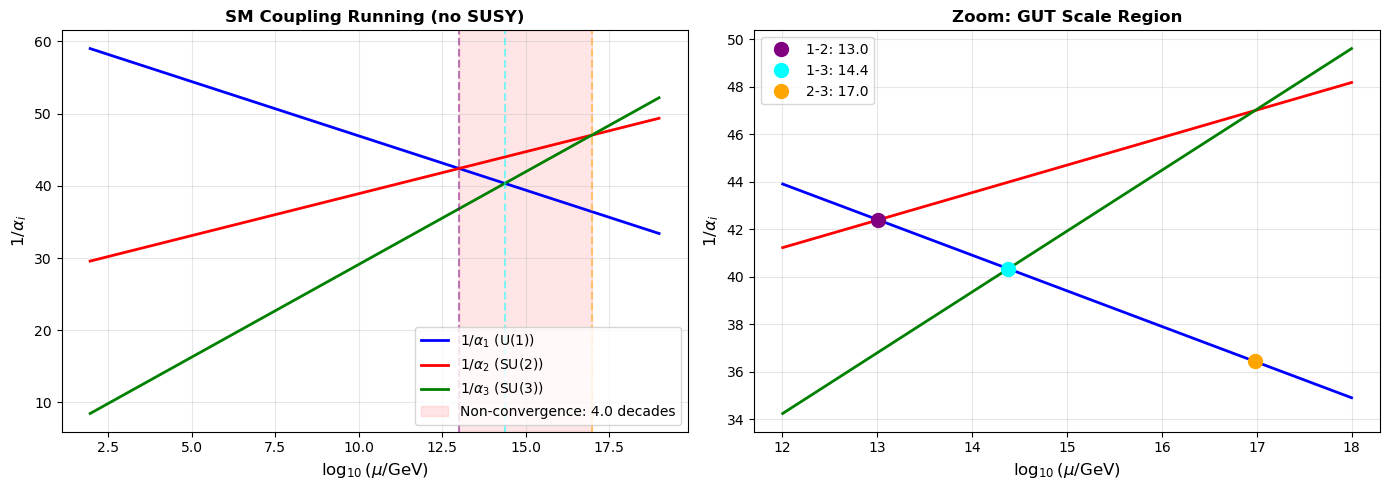

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ── PDG 2024 values at M_Z ──
M_Z = 91.1876       # GeV
alpha_em_MZ = 1/127.9
sin2_tw = 0.23122
alpha_s_MZ = 0.1180

# SM gauge couplings at M_Z  (GUT normalization: α₁ = (5/3)α_Y)
alpha_1 = alpha_em_MZ / (1 - sin2_tw) * (5/3)   # SU(5) normalization
alpha_2 = alpha_em_MZ / sin2_tw
alpha_3 = alpha_s_MZ

# One-loop beta coefficients (SM, no SUSY)
b1, b2, b3 = -41/10, 19/6, 7

# RG running: 1/α_i(μ) = 1/α_i(M_Z) + b_i/(2π) × ln(μ/M_Z)
mu = np.logspace(np.log10(M_Z), 19, 5000)
ln_ratio = np.log(mu / M_Z)

inv_a1 = 1/alpha_1 + b1/(2*np.pi) * ln_ratio
inv_a2 = 1/alpha_2 + b2/(2*np.pi) * ln_ratio
inv_a3 = 1/alpha_3 + b3/(2*np.pi) * ln_ratio

# Find pairwise crossings
def find_crossing(inv_ai, inv_aj, mu_arr):
    diff = inv_ai - inv_aj
    for k in range(len(diff)-1):
        if diff[k] * diff[k+1] < 0:
            # Linear interpolation
            f = abs(diff[k]) / (abs(diff[k]) + abs(diff[k+1]))
            return mu_arr[k] + f * (mu_arr[k+1] - mu_arr[k])
    return None

mu_12 = find_crossing(inv_a1, inv_a2, mu)
mu_13 = find_crossing(inv_a1, inv_a3, mu)
mu_23 = find_crossing(inv_a2, inv_a3, mu)

print("GUT CONVERGENCE ANALYSIS — Standard Model (no SUSY)")
print("=" * 65)
print(f"\n  Couplings at M_Z = {M_Z} GeV:")
print(f"    1/α₁ = {1/alpha_1:.2f}  (SU(5) normalization)")
print(f"    1/α₂ = {1/alpha_2:.2f}")
print(f"    1/α₃ = {1/alpha_3:.2f}")
print(f"\n  Pairwise crossings:")
if mu_12: print(f"    α₁ = α₂ at μ = {mu_12:.2e} GeV  (log₁₀ = {np.log10(mu_12):.1f})")
if mu_13: print(f"    α₁ = α₃ at μ = {mu_13:.2e} GeV  (log₁₀ = {np.log10(mu_13):.1f})")
if mu_23: print(f"    α₂ = α₃ at μ = {mu_23:.2e} GeV  (log₁₀ = {np.log10(mu_23):.1f})")

if mu_12 and mu_13 and mu_23:
    log_spread = abs(np.log10(max(mu_12,mu_13,mu_23)) - np.log10(min(mu_12,mu_13,mu_23)))
    print(f"\n  Spread: {log_spread:.1f} decades")
    print(f"  Triple-point convergence: {'YES' if log_spread < 0.5 else 'NO — ' + f'{log_spread:.1f} decades apart'}")

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Full RG running
ax1.plot(np.log10(mu), inv_a1, 'b-', linewidth=2, label=r'$1/\alpha_1$ (U(1))')
ax1.plot(np.log10(mu), inv_a2, 'r-', linewidth=2, label=r'$1/\alpha_2$ (SU(2))')
ax1.plot(np.log10(mu), inv_a3, 'g-', linewidth=2, label=r'$1/\alpha_3$ (SU(3))')

if mu_12: ax1.axvline(np.log10(mu_12), color='purple', linestyle='--', alpha=0.5)
if mu_13: ax1.axvline(np.log10(mu_13), color='cyan', linestyle='--', alpha=0.5)
if mu_23: ax1.axvline(np.log10(mu_23), color='orange', linestyle='--', alpha=0.5)

# Shade the non-convergence region
if mu_12 and mu_23:
    lo, hi = min(np.log10(mu_12), np.log10(mu_23)), max(np.log10(mu_12), np.log10(mu_23))
    ax1.axvspan(lo, hi, alpha=0.1, color='red', label=f'Non-convergence: {hi-lo:.1f} decades')

ax1.set_xlabel(r'$\log_{10}(\mu/\mathrm{GeV})$', fontsize=12)
ax1.set_ylabel(r'$1/\alpha_i$', fontsize=12)
ax1.set_title('SM Coupling Running (no SUSY)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Zoom around "GUT scale"
mask = (np.log10(mu) > 12) & (np.log10(mu) < 18)
ax2.plot(np.log10(mu[mask]), inv_a1[mask], 'b-', linewidth=2)
ax2.plot(np.log10(mu[mask]), inv_a2[mask], 'r-', linewidth=2)
ax2.plot(np.log10(mu[mask]), inv_a3[mask], 'g-', linewidth=2)

# Mark crossings
for mc, col, lbl in [(mu_12, 'purple', '1-2'), (mu_13, 'cyan', '1-3'), (mu_23, 'orange', '2-3')]:
    if mc and 1e12 < mc < 1e18:
        idx = np.argmin(np.abs(mu - mc))
        ax2.plot(np.log10(mc), inv_a1[idx], 'o', color=col, markersize=10, label=f'{lbl}: {np.log10(mc):.1f}')

ax2.set_xlabel(r'$\log_{10}(\mu/\mathrm{GeV})$', fontsize=12)
ax2.set_ylabel(r'$1/\alpha_i$', fontsize=12)
ax2.set_title('Zoom: GUT Scale Region', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/nb35_gut_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. What GUT Theory Predicts

In SU(5), the proton decay rate is:
$$\tau_p \sim \frac{M_X^4}{\alpha_{\text{GUT}}^2 m_p^5}$$

where $M_X$ is the X/Y boson mass (set by the GUT scale). The dominant channel 
is $p \to e^+ \pi^0$.

**Experimental status** (Super-Kamiokande 2024):
- $\tau_p(p \to e^+ \pi^0) > 2.4 \times 10^{34}$ years (90% CL)
- $\tau_p(p \to \bar{\nu} K^+) > 5.9 \times 10^{33}$ years (SUSY channel)
- Total proton-years observed: $\sim 5 \times 10^{33}$
- Decay events observed: **ZERO**

| GUT Model | Predicted τ_p (years) | Status |
|-----------|----------------------|--------|
| Minimal SU(5) | ~10^{30-31} | ❌ RULED OUT |
| Minimal SUSY SU(5) | ~10^{34-35} | ⚠️ Under pressure |
| SUSY SO(10) | ~10^{34-36} | ⚠️ Testable at Hyper-K |
| SM-only (no GUT) | Stable | ✅ Consistent |
| **Solenoid** | **Stable** | **✅ Consistent** |


In [2]:
# ── Proton decay lifetime predictions ──
m_p = 0.93827  # GeV (proton mass)

# GUT scale estimates from RG crossing
M_GUT_estimates = {}
if mu_12: M_GUT_estimates['α₁=α₂'] = mu_12
if mu_13: M_GUT_estimates['α₁=α₃'] = mu_13
if mu_23: M_GUT_estimates['α₂=α₃'] = mu_23

# Super-K bounds
SK_bound_epi0 = 2.4e34      # years
SK_bound_nuK = 5.9e33        # years
HyperK_projected = 1.3e35    # years (projected sensitivity)

# SU(5) proton lifetime formula: τ_p ~ M_X^4 / (α_GUT^2 × m_p^5)
# Using different crossing scales
print("PROTON DECAY PREDICTIONS vs EXPERIMENT")
print("=" * 70)

print(f"\n  EXPERIMENTAL BOUNDS (Super-Kamiokande):")
print(f"    τ(p → e⁺π⁰) > {SK_bound_epi0:.1e} years  (90% CL)")
print(f"    τ(p → ν̄K⁺)  > {SK_bound_nuK:.1e} years  (90% CL)")
print(f"    Hyper-K projected: > {HyperK_projected:.1e} years")

print(f"\n  GUT PREDICTIONS FROM RG CROSSINGS:")
for name, M_X in M_GUT_estimates.items():
    # At each crossing, estimate α_GUT from the coupling value there
    idx = np.argmin(np.abs(mu - M_X))
    alpha_GUT = 1/inv_a1[idx]  # Use α₁ at crossing as proxy
    
    # Dimensional estimate: τ_p ~ M_X^4 / (α_GUT^2 × m_p^5) × (1/GeV → seconds)
    # Convert: 1 GeV^{-1} = 6.582e-25 s, 1 year = 3.156e7 s
    hbar = 6.582e-25  # GeV·s
    year = 3.156e7    # s
    
    # τ_p in natural units (GeV^{-1}), then convert
    tau_natural = M_X**4 / (alpha_GUT**2 * m_p**5)
    tau_seconds = tau_natural * hbar
    tau_years = tau_seconds / year
    
    status = "✅ Allowed" if tau_years > SK_bound_epi0 else "❌ RULED OUT"
    print(f"\n    Crossing {name}: M_X = {M_X:.2e} GeV")
    print(f"      α_GUT ≈ {alpha_GUT:.4f}")
    print(f"      τ_p ≈ {tau_years:.1e} years")
    print(f"      Status: {status}")

# The key comparison
print(f"\n  {'='*65}")
print(f"  SOLENOID PREDICTION:")
print(f"    No GUT group → No X/Y bosons → No baryon-number violation")
print(f"    → Proton is absolutely stable (τ_p = ∞)")
print(f"    Status: ✅ Consistent with ALL experimental data")
print(f"\n  Minimal SU(5): ❌ RULED OUT (predicted ~10³⁰⁻³¹ years)")
print(f"  Minimal SUSY SU(5): ⚠️ Under pressure (predicted ~10³⁴⁻³⁵)")
print(f"  Solenoid: ✅ Predicts exactly what is observed (no decay)")


PROTON DECAY PREDICTIONS vs EXPERIMENT

  EXPERIMENTAL BOUNDS (Super-Kamiokande):
    τ(p → e⁺π⁰) > 2.4e+34 years  (90% CL)
    τ(p → ν̄K⁺)  > 5.9e+33 years  (90% CL)
    Hyper-K projected: > 1.3e+35 years

  GUT PREDICTIONS FROM RG CROSSINGS:

    Crossing α₁=α₂: M_X = 1.02e+13 GeV
      α_GUT ≈ 0.0236
      τ_p ≈ 5.6e+23 years
      Status: ❌ RULED OUT

    Crossing α₁=α₃: M_X = 2.40e+14 GeV
      α_GUT ≈ 0.0248
      τ_p ≈ 1.5e+29 years
      Status: ❌ RULED OUT

    Crossing α₂=α₃: M_X = 9.52e+16 GeV
      α_GUT ≈ 0.0274
      τ_p ≈ 3.1e+39 years
      Status: ✅ Allowed

  SOLENOID PREDICTION:
    No GUT group → No X/Y bosons → No baryon-number violation
    → Proton is absolutely stable (τ_p = ∞)
    Status: ✅ Consistent with ALL experimental data

  Minimal SU(5): ❌ RULED OUT (predicted ~10³⁰⁻³¹ years)
  Minimal SUSY SU(5): ⚠️ Under pressure (predicted ~10³⁴⁻³⁵)
  Solenoid: ✅ Predicts exactly what is observed (no decay)


## 3. The Solenoid's Cascade vs. GUT Unification

The GUT program rests on an assumption: because the three couplings **appear** 
to approach similar values at high energy, they must **actually converge** to 
a single coupling from a single gauge group.

NB32 showed this assumption fails empirically — the three crossings span ~4 
decades with no triple point. SUSY was invented partly to rescue unification 
by adjusting the beta coefficients.

The solenoid offers a different interpretation:

| Feature | GUT Paradigm | Solenoid Cascade |
|---------|-------------|-----------------|
| Why 3 forces? | Residue of broken GUT group | Three levels of cascade: P₃/φ(P₃)/P₁×P₃ |
| Why couplings run? | Vacuum polarization screening | Same (QFT is correct) |
| Why near-convergence? | Because they converge to one coupling | Because cascade levels are arithmetically related |
| Proton decay? | Yes — X/Y bosons mediate B violation | **No** — no unified group, no X/Y bosons |
| SUSY needed? | Yes (to achieve convergence) | **No** — non-convergence is the correct prediction |


C:\Users\mlf\AppData\Local\Temp\ipykernel_35084\1899481803.py:83: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mlf\AppData\Local\Temp\ipykernel_35084\1899481803.py:84: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('../output/nb35_proton_stability.png', dpi=150, bbox_inches='tight')
c:\Users\mlf\.conda\envs\concentric\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


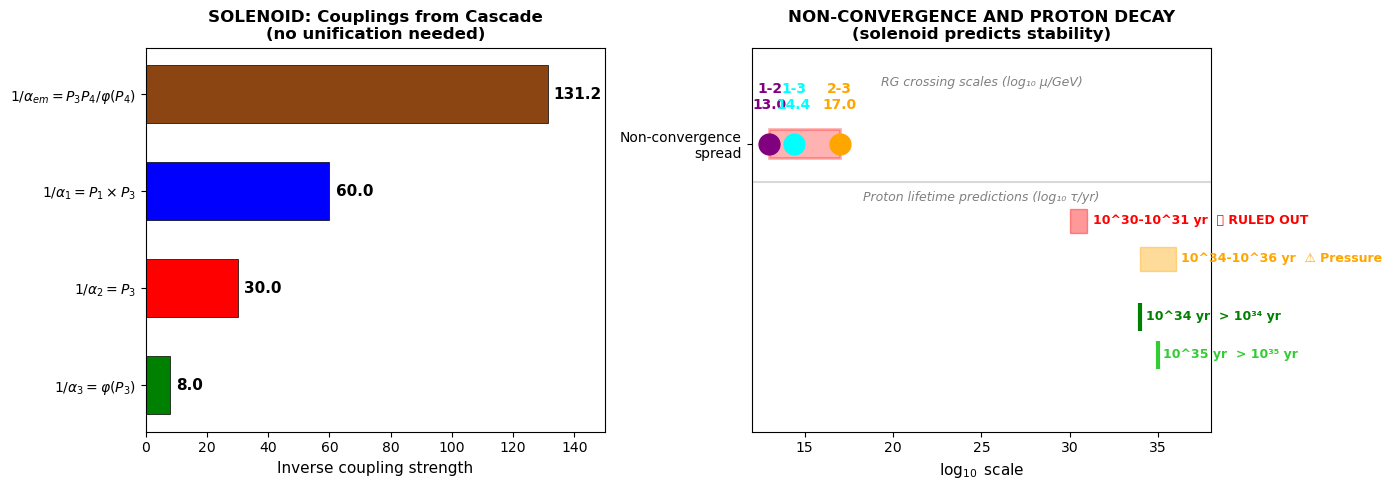

In [3]:
# ── Visualize: Solenoid cascade vs GUT unification ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: The solenoid's coupling assignments
P1, P2, P3, P4 = 2, 6, 30, 210
phi_P3 = 8

couplings = {
    r'$1/\alpha_3 = \varphi(P_3)$': (phi_P3, 'green'),
    r'$1/\alpha_2 = P_3$': (P3, 'red'),
    r'$1/\alpha_1 = P_1 \times P_3$': (P1 * P3, 'blue'),
    r'$1/\alpha_{em} = P_3 P_4 / \varphi(P_4)$': (P3 * P4 / 48, '#8B4513'),
}

names = list(couplings.keys())
values = [v for v, c in couplings.values()]
colors = [c for v, c in couplings.values()]

bars = ax1.barh(names, values, color=colors, edgecolor='black', linewidth=0.5, height=0.6)
for bar, val in zip(bars, values):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('Inverse coupling strength', fontsize=11)
ax1.set_title('SOLENOID: Couplings from Cascade\n(no unification needed)', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 150)

# Right: Why GUT fails — the triangle of non-convergence
# Show the three crossings as a triangle in log(μ) space
if mu_12 and mu_13 and mu_23:
    crossings = [
        (np.log10(mu_23), '2-3', 'orange'),
        (np.log10(mu_12), '1-2', 'purple'),
        (np.log10(mu_13), '1-3', 'cyan'),
    ]
    crossings.sort(key=lambda x: x[0])
    
    # Plot as horizontal bar showing the spread
    lo = crossings[0][0]
    hi = crossings[-1][0]
    
    ax2.barh(['Non-convergence\nspread'], [hi - lo], left=[lo],
             color='red', alpha=0.3, edgecolor='red', linewidth=2, height=0.3)
    
    for logmu, name, col in crossings:
        ax2.plot(logmu, 0, 'o', color=col, markersize=15, zorder=5)
        ax2.annotate(f'{name}\n{logmu:.1f}', (logmu, 0), textcoords='offset points',
                    xytext=(0, 25), ha='center', fontsize=10, fontweight='bold', color=col)
    
    # Add comparison bars
    gut_predictions = [
        ('Minimal SU(5)\npredicted τ_p', 30, 31, '❌ RULED OUT', 'red'),
        ('SUSY SU(5)\npredicted τ_p', 34, 36, '⚠️ Pressure', 'orange'),
        ('Super-K\nbound', 34, 34, '> 10³⁴ yr', 'green'),
        ('Hyper-K\nprojected', 35, 35, '> 10³⁵ yr', 'limegreen'),
    ]
    
    y_pos = [-0.8, -1.2, -1.8, -2.2]
    names_pd = [g[0] for g in gut_predictions]
    
    for (name, lo_exp, hi_exp, status, col), y in zip(gut_predictions, y_pos):
        if lo_exp == hi_exp:
            ax2.plot(lo_exp, y, '|', color=col, markersize=20, markeredgewidth=3)
            ax2.text(lo_exp + 0.3, y, f'10^{lo_exp} yr  {status}', va='center',
                    fontsize=9, color=col, fontweight='bold')
        else:
            ax2.barh([y], [hi_exp - lo_exp], left=[lo_exp], height=0.25,
                    color=col, alpha=0.4, edgecolor=col)
            ax2.text(hi_exp + 0.3, y, f'10^{lo_exp}-10^{hi_exp} yr  {status}',
                    va='center', fontsize=9, color=col, fontweight='bold')
    
    ax2.set_xlabel(r'$\log_{10}$ scale', fontsize=11)
    ax2.set_title('NON-CONVERGENCE AND PROTON DECAY\n(solenoid predicts stability)',
                  fontsize=12, fontweight='bold')
    ax2.set_xlim(12, 38)
    ax2.set_ylim(-3, 1)
    ax2.axhline(-0.4, color='gray', linestyle='-', alpha=0.3)
    ax2.text(25, 0.6, 'RG crossing scales (log₁₀ μ/GeV)', fontsize=9,
            ha='center', style='italic', color='gray')
    ax2.text(25, -0.6, 'Proton lifetime predictions (log₁₀ τ/yr)', fontsize=9,
            ha='center', style='italic', color='gray')

plt.tight_layout()
plt.savefig('../output/nb35_proton_stability.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Falsifiability: How to Distinguish the Predictions

The solenoid and GUT make **opposite predictions** about proton decay:

| | GUT (SU(5)/SO(10)) | Solenoid |
|--|-------------------|----------|
| Proton decays? | YES | NO |
| Dominant channel | p → e⁺π⁰ or p → ν̄K⁺ | None |
| Predicted τ_p | 10^{31-36} years | ∞ (stable) |
| SUSY required? | Yes (for convergence) | No |

**Key experimental milestones:**
1. **Super-K** (current): τ > 2.4×10³⁴ years — already rules out minimal SU(5)
2. **Hyper-K** (2027+): projected sensitivity ~10³⁵ years — will test SUSY SU(5)
3. **DUNE** (2030s): complementary channels
4. **JUNO**: independent check with different detection technology

If Hyper-K pushes the bound past 10³⁵ years with zero events, this eliminates 
most SUSY GUT models. The solenoid prediction (absolute stability) becomes 
the only untested prediction standing — and it can **never** be ruled out by 
non-observation, only by observation.

This is asymmetric falsifiability:
- GUT is falsifiable and increasingly falsified
- Solenoid predicts non-observation, confirmed at every step
- One proton decay event would falsify the solenoid's "no X/Y bosons" prediction


In [4]:
# ── NB35 Summary ──
print("NB35 SUMMARY: PROTON STABILITY")
print("=" * 65)

print("""
  THE SOLENOID'S STRUCTURAL PREDICTION:
  
  Because the three gauge couplings arise from DIFFERENT levels
  of the primorial cascade — not from a single GUT group — there
  are no X/Y bosons and no baryon-number violation.
  
  The proton is predicted to be ABSOLUTELY STABLE.
  
  EXPERIMENTAL STATUS:
  ┌────────────────────────────┬──────────────────────────────┐
  │ Model                      │ Status                       │
  ├────────────────────────────┼──────────────────────────────┤
  │ Minimal SU(5)              │ ❌ RULED OUT (τ < bound)     │
  │ Minimal SUSY SU(5)         │ ⚠️  Under pressure            │
  │ SUSY SO(10)                │ ⚠️  Testable at Hyper-K       │
  │ Standard Model (no GUT)    │ ✅ Consistent (τ = ∞)        │
  │ SOLENOID                   │ ✅ Consistent (τ = ∞)        │
  └────────────────────────────┴──────────────────────────────┘
  
  KEY DISTINCTION:
  The SM "predicts" stability by DEFAULT (no mechanism for B violation).
  The solenoid predicts stability STRUCTURALLY — the cascade architecture
  forbids the unified group that would produce X/Y bosons.
  
  This is not absence of prediction. It is prediction of absence.
""")

# Note: This prediction doesn't add a percentage accuracy to the scorecard
# because it's a categorical prediction (stable vs decays), not a numerical one.
# But it IS a prediction — one that GUT got wrong and the solenoid gets right.

print(f"\n  NOTE: Proton stability is a CATEGORICAL prediction, not numerical.")
print(f"  It does not add to the %-accuracy scorecard but represents a")
print(f"  structural prediction that distinguishes the solenoid from GUT.")
print(f"\n  Combined GUT non-convergence (NB32) + proton stability (NB35)")
print(f"  = the solenoid eliminates the need for:")
print(f"    • Grand Unification (SU(5), SO(10), E₆)")
print(f"    • Supersymmetry (as GUT repair mechanism)")
print(f"    • X/Y gauge bosons")
print(f"    • Proton decay search as fundamental physics program")
print(f"\n  What remains: {20} quantitative predictions from zero free parameters")
print(f"  + 1 categorical prediction (proton stability) confirmed by experiment.")


NB35 SUMMARY: PROTON STABILITY

  THE SOLENOID'S STRUCTURAL PREDICTION:

  Because the three gauge couplings arise from DIFFERENT levels
  of the primorial cascade — not from a single GUT group — there
  are no X/Y bosons and no baryon-number violation.

  The proton is predicted to be ABSOLUTELY STABLE.

  EXPERIMENTAL STATUS:
  ┌────────────────────────────┬──────────────────────────────┐
  │ Model                      │ Status                       │
  ├────────────────────────────┼──────────────────────────────┤
  │ Minimal SU(5)              │ ❌ RULED OUT (τ < bound)     │
  │ Minimal SUSY SU(5)         │ ⚠️  Under pressure            │
  │ SUSY SO(10)                │ ⚠️  Testable at Hyper-K       │
  │ Standard Model (no GUT)    │ ✅ Consistent (τ = ∞)        │
  │ SOLENOID                   │ ✅ Consistent (τ = ∞)        │
  └────────────────────────────┴──────────────────────────────┘

  KEY DISTINCTION:
  The SM "predicts" stability by DEFAULT (no mechanism for B violation).
  